# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [7]:
import os

print(os.listdir('/content'))

['.config', 'airbnb_london.csv', 'sample_data']


In [8]:
import pandas as pd
import plotly.express as px
import numpy as np

# Load dataset
df = pd.read_csv('airbnb_london.csv')

print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))

Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [9]:
p95 = df['price'].quantile(0.95)

df_cap = df[df['price'] <= p95]

print(f"95th percentile price: £{p95:.0f}")

95th percentile price: £373


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


In [10]:
# Task 1

# Filter only Entire home and Private room
df_hist = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])]

# Calculate medians
entire_median = df_hist[df_hist['room_type'] == 'Entire home/apt']['price'].median()
private_median = df_hist[df_hist['room_type'] == 'Private room']['price'].median()

# Create histogram
fig = px.histogram(
    df_hist,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=40,
    color_discrete_map={
        'Entire home/apt': 'darkblue',
        'Private room': 'orange'
    },
    title='Entire homes have a higher and wider price distribution than private rooms'
)

# Add median lines
fig.add_vline(
    x=entire_median,
    line_dash='dash',
    line_color='darkblue',
    annotation_text=f'Entire home median: £{entire_median:.0f}',
    annotation_position='top'
)

fig.add_vline(
    x=private_median,
    line_dash='dash',
    line_color='orange',
    annotation_text=f'Private room median: £{private_median:.0f}',
    annotation_position='top'
)

# Update layout
fig.update_layout(
    xaxis_title='Price (£)',
    yaxis_title='Number of Listings'
)

fig.show()

## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

In [11]:
# Task 1

# Filter only Entire home and Private room
df_hist = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])]

# Calculate medians
entire_median = df_hist[df_hist['room_type'] == 'Entire home/apt']['price'].median()
private_median = df_hist[df_hist['room_type'] == 'Private room']['price'].median()

# Create histogram
fig = px.histogram(
    df_hist,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=40,
    color_discrete_map={
        'Entire home/apt': 'darkblue',
        'Private room': 'orange'
    },
    title='Entire homes have a higher and wider price distribution than private rooms'
)

# Add median lines
fig.add_vline(
    x=entire_median,
    line_dash='dash',
    line_color='darkblue',
    annotation_text=f'Entire home median: £{entire_median:.0f}',
    annotation_position='top'
)

fig.add_vline(
    x=private_median,
    line_dash='dash',
    line_color='orange',
    annotation_text=f'Private room median: £{private_median:.0f}',
    annotation_position='top'
)

# Update layout
fig.update_layout(
    xaxis_title='Price (£)',
    yaxis_title='Number of Listings'
)

fig.show()

In [13]:
df.columns

Index(['neighbourhood', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'availability_365', 'reviews_per_month'],
      dtype='object')

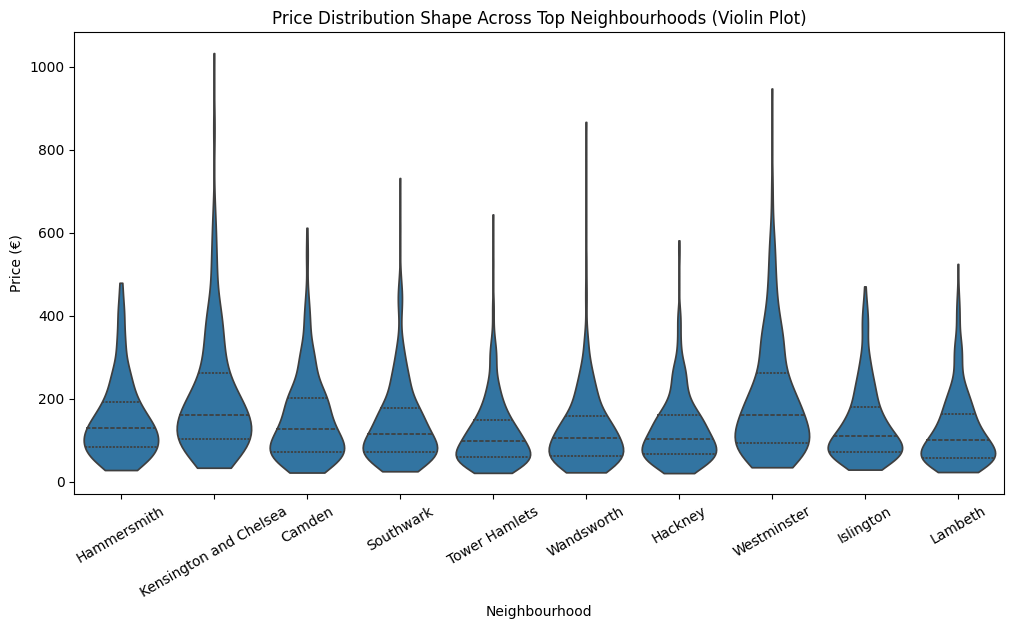

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

top_neigh = df['neighbourhood'].value_counts().nlargest(10).index
df_filtered = df[df['neighbourhood'].isin(top_neigh)]

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df_filtered,
    x='neighbourhood',
    y='price',
    inner='quartile',
    cut=0,
    density_norm='width'
)

plt.title("Price Distribution Shape Across Top Neighbourhoods (Violin Plot)")
plt.xlabel("Neighbourhood")
plt.ylabel("Price (€)")
plt.xticks(rotation=30)

plt.show()

The violin plot reveals a consistent right-skewed price distribution across London neighbourhoods, indicating that most listings are concentrated in lower to mid price ranges with occasional high-end outliers. Central and premium areas such as Kensington & Chelsea and Westminster show wider distribution spreads, reflecting higher variability and luxury listings, while areas like Hackney and Tower Hamlets exhibit tighter distributions, suggesting more affordable and consistent pricing structures.